### Impot libraries

In [48]:
import pandas as pd
import torch
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset
from torchvision import transforms

### Reading data

In [56]:
class ImageDataset(Dataset):
    def __init__(self, data_dir, folder, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []

        folder_dir = os.path.join(data_dir, folder)
        for class_folder in os.listdir(folder_dir):
            class_path = os.path.join(folder_dir, class_folder)
                
            if os.path.isdir(class_path): 
                for filename in os.listdir(class_path):
                    if filename.endswith(".jpg") or filename.endswith(".png"): 
                        self.image_paths.append(os.path.join(class_path, filename))
                        self.labels.append(int(class_folder))

        self.labels = np.array(self.labels)


    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label).long()
    

In [28]:
data_dir = "../data"

In [72]:
train_dataset = ImageDataset(data_dir, folder='train', transform=None)
val_dataset = ImageDataset(data_dir, folder='val', transform=None)
test_dataset = ImageDataset(data_dir, folder='test', transform=None)

In [42]:
unique_train_labels = np.unique(train_dataset.labels)
unique_val_labels = np.unique(val_dataset.labels)
unique_test_labels = np.unique(test_dataset.labels)

print("Unique train labels:", unique_train_labels)
print("train size:", len(train_dataset))
print("Unique validation labels:", unique_val_labels)
print("val size:", len(val_dataset))
print("Unique test labels:", unique_test_labels)
print("test size:", len(test_dataset))

Unique train labels: [0 1 2 3 4 5 6]
train size: 28709
Unique validation labels: [0 1 2 3 4 5 6]
val size: 3589
Unique test labels: [0 1 2 3 4 5 6]
test size: 3589


In [70]:
def transform_data(data_dir, folder, sample_number, transform=None):
    if transform is None:
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
    
    dataset = ImageDataset(data_dir=data_dir, folder=folder, transform=transform)
    image, label = dataset[sample_number] 
    image_np = np.array(image)
   
    if dataset[sample_number][0] == 3:
        image_np = np.transpose(image_np, (1, 2, 0))

    print('Label: ', label.item())
    plt.imshow(image_np)
    plt.axis('off')
    plt.show()
    

Label:  3


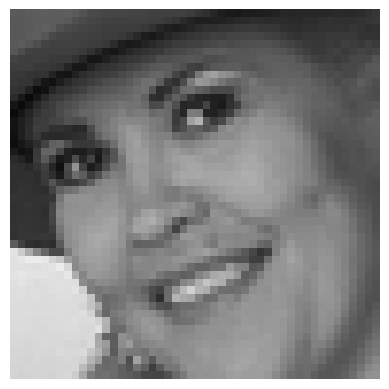

In [71]:
transform_data(data_dir, folder='train', sample_number=1)